In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
# Read the image in grayscale
source = cv2.imread("cat1.jpg", 0)
reference = cv2.imread("cat2.jpg", 0)

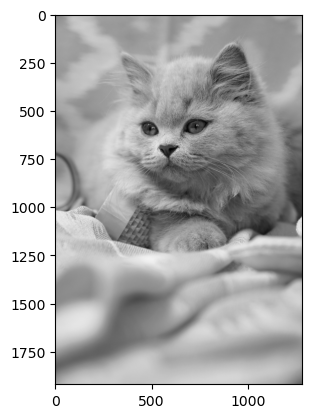

In [3]:
# show the source image
plt.imshow(source, cmap='gray')

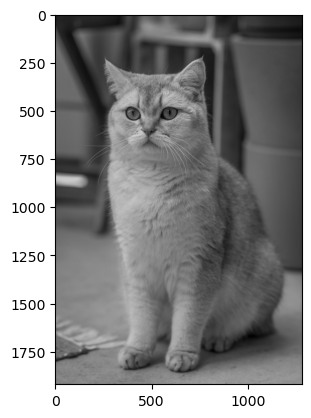

In [4]:
# show the reference image
plt.imshow(reference, cmap='gray')

In [5]:
# Function to compute histogram manually
def compute_histogram(image):
    hist = [0] * 256
    rows, cols = image.shape

    for i in range(rows):
        for j in range(cols):
            hist[image[i, j]] += 1

    return hist

In [6]:
# Compute histograms
src_hist = compute_histogram(source)
ref_hist = compute_histogram(reference)

In [7]:
# Compute PDF
src_total = source.shape[0] * source.shape[1]
ref_total = reference.shape[0] * reference.shape[1]

src_pdf = [h / src_total for h in src_hist]
ref_pdf = [h / ref_total for h in ref_hist]

In [8]:
# Compute CDF
src_cdf = [0] * 256
ref_cdf = [0] * 256

src_cdf[0] = src_pdf[0]
ref_cdf[0] = ref_pdf[0]

for i in range(1, 256):
    src_cdf[i] = src_cdf[i - 1] + src_pdf[i]
    ref_cdf[i] = ref_cdf[i - 1] + ref_pdf[i]

In [9]:
# Create Mapping Table
mapping = [0] * 256

for i in range(256):
    diff = abs(src_cdf[i] - ref_cdf[0])
    index = 0

    for j in range(256):
        if abs(src_cdf[i] - ref_cdf[j]) < diff:
            diff = abs(src_cdf[i] - ref_cdf[j])
            index = j

    mapping[i] = index

In [10]:
# Apply Mapping
matched = np.zeros_like(source)

rows, cols = source.shape

for i in range(rows):
    for j in range(cols):
        matched[i, j] = mapping[source[i, j]]

In [11]:
# Histogram of matched image
matched_hist = compute_histogram(matched)

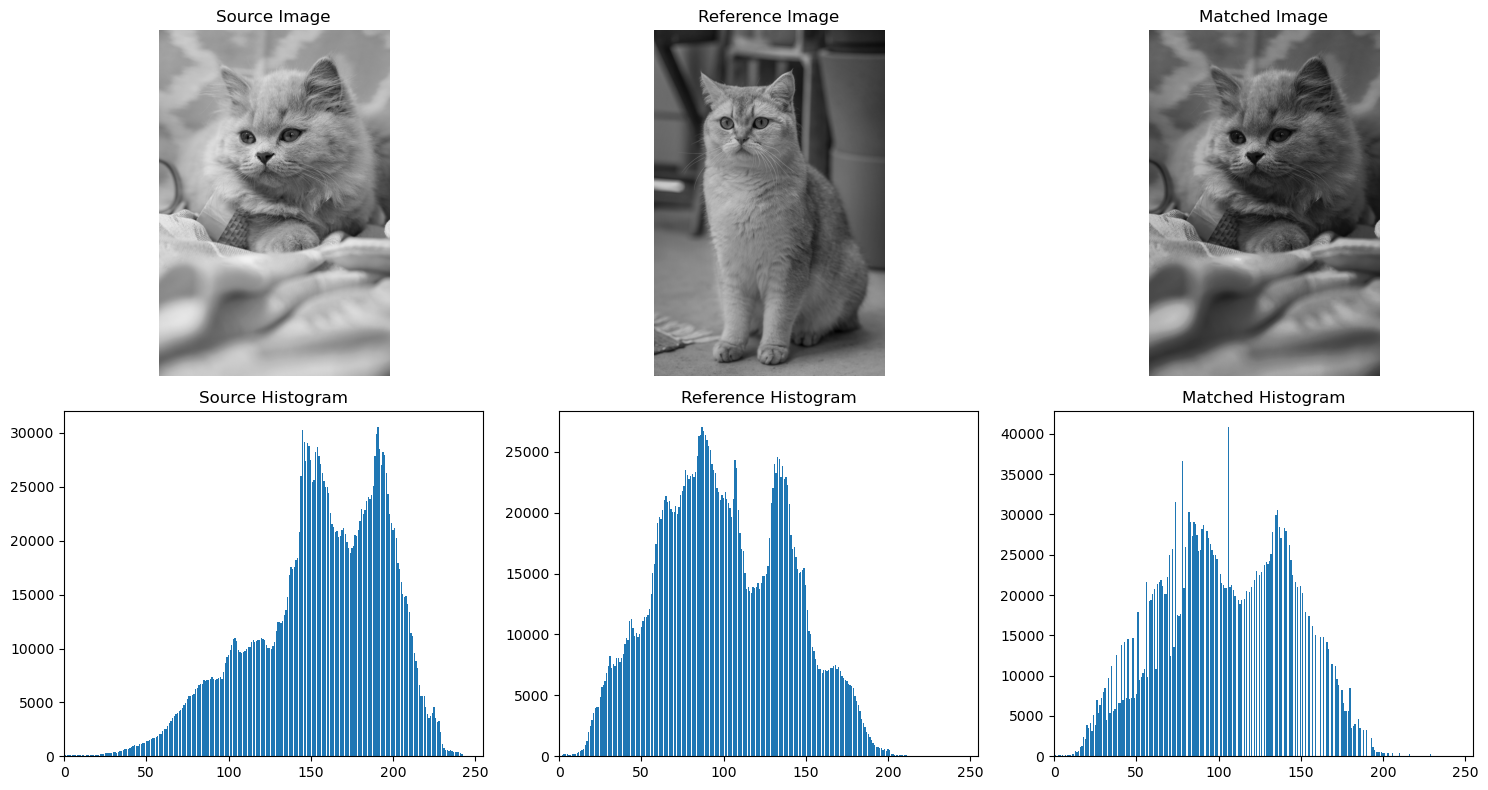

In [12]:
# Display Results
plt.figure(figsize=(15,8))

plt.subplot(2,3,1)
plt.imshow(source, cmap='gray')
plt.title("Source Image")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(reference, cmap='gray')
plt.title("Reference Image")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(matched, cmap='gray')
plt.title("Matched Image")
plt.axis('off')

plt.subplot(2,3,4)
plt.bar(range(256), src_hist)
plt.title("Source Histogram")
plt.xlim([0,255])

plt.subplot(2,3,5)
plt.bar(range(256), ref_hist)
plt.title("Reference Histogram")
plt.xlim([0,255])

plt.subplot(2,3,6)
plt.bar(range(256), matched_hist)
plt.title("Matched Histogram")
plt.xlim([0,255])

plt.tight_layout()
plt.show()